# Assignment 2: Encoding & Transformation Impact
**Course:** Feature Engineering & MLOps (Unit 2, Topics 1 & 2)  
**Student Name:** Sakshi Kore  
**Assignment No:** 2  
**Topic:** Categorical Encoding (2.1) + Skewness Transformations & Model Comparison (2.2)  

---

### Assignment Objectives & Workflow
This assignment explores how feature engineering choices interact with different machine learning model architectures:
1. **Part 2.1 — Categorical Encoding:** One-hot encode nominal categorical features (`city`, `course`, `batch_type`) with train-only fitting discipline, and verify safe handling of test categories with `handle_unknown='ignore'`.
2. **Part 2.2 — Skewness Diagnosis & Transformation:** Measure the skewness of `weekly_study_hours`, select an appropriate mathematical transformation (`log1p`) based on class decision criteria, and evaluate the skewness reduction.
3. **Controlled Experiment:** Construct two identical feature sets differing only in the representation of `weekly_study_hours` (Version A = raw, Version B = log-transformed).
4. **Model Comparison:** Train **Linear Regression** and **Decision Tree Regressor** on both versions and evaluate on the test set using $R^2$ and $RMSE$.
5. **Written Conclusion:** Explain why Linear Regression responds to feature compression while Decision Trees remain invariant.
6. **Bonus (Optional, +10% Extra Credit):** Evaluate a distance-based **K-Nearest Neighbors Regressor (KNN)** to show how Euclidean distance calculations are impacted by feature scale.

## 1. Imports and Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas.api.types as ptypes

pd.set_option('display.max_columns', None)
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries and plotting settings loaded.")

Libraries and plotting settings loaded.


## 2. `CustomImputer` Class (from Assignment 1)

As instructed in the assignment guidelines, we first impute missing values in `weekly_study_hours` and `prev_exam_score` using our `CustomImputer` class, fitting only on the training data.

In [2]:
class CustomImputer(BaseEstimator, TransformerMixin):
    """Custom imputer class adhering to scikit-learn estimator conventions."""
    def __init__(self, numeric_strategy='median', categorical_strategy='most_frequent',
                 add_missing_indicator=False):
        self.numeric_strategy = numeric_strategy
        self.categorical_strategy = categorical_strategy
        self.add_missing_indicator = add_missing_indicator

    def fit(self, X, y=None):
        df_in = pd.DataFrame(X).copy()
        self.columns_ = list(df_in.columns)
        self.num_cols_ = [c for c in df_in.columns if ptypes.is_numeric_dtype(df_in[c])]
        self.fill_values_ = {}
        for col in df_in.columns:
            non_nulls = df_in[col].dropna()
            if col in self.num_cols_:
                self.fill_values_[col] = non_nulls.mean() if self.numeric_strategy == 'mean' else non_nulls.median()
            else:
                modes = non_nulls.mode()
                self.fill_values_[col] = modes.iloc[0] if len(modes) else np.nan
        return self

    def transform(self, X):
        check_is_fitted(self, 'fill_values_')
        df_out = pd.DataFrame(X).copy()
        for col in df_out.columns:
            if col in self.fill_values_ and df_out[col].isnull().any():
                df_out[col] = df_out[col].fillna(self.fill_values_[col])
        return df_out

## 3. Dataset Loading and Feature Selection

We load `student_performance_raw.csv` and inspect the predictors required for this assignment:
- **Nominal categorical:** `city`, `course`, `batch_type`
- **Skewed numeric (target of transformation):** `weekly_study_hours`
- **Additional numeric predictors:** `attendance_pct`, `prev_exam_score`, `doubt_sessions_attended`
- **Regression target:** `final_score`

In [3]:
data_file = '../data/raw/student_performance_raw.csv'
if not os.path.exists(data_file):
    data_file = 'data/raw/student_performance_raw.csv'

df = pd.read_csv(data_file)
print(f"Dataset shape: {df.shape}")
print("\nMissing count in columns needing imputation:")
print(df[['weekly_study_hours', 'prev_exam_score']].isnull().sum())

Dataset shape: (600, 17)

Missing count in columns needing imputation:
weekly_study_hours    36
prev_exam_score       25
dtype: int64


## Part 2.1 — One-Hot Encoding

### Why are `city`, `course`, and `batch_type` Nominal rather than Ordinal?
- `city` (e.g., Mumbai, Delhi, Patna), `course` (JEE Main, NEET, JEE Advanced, Foundation), and `batch_type` (Weekday, Weekend) are **nominal** categorical variables because their categories have no natural mathematical hierarchy or rank order. For example, Mumbai is not "greater than" Delhi, and NEET is not "higher than" JEE Main.
- In contrast, ordinal variables like `income_bracket` have a natural progression (`<5L` < `5-10L` < `10-20L` < `>20L`).
- If we encoded nominal categories with arbitrary numbers (0, 1, 2...), regression models would treat them as numerical quantities and try to fit artificial slopes between unrelated cities. One-hot encoding creates separate 0/1 binary indicator columns for each category, avoiding false ordering.

### 2.1.1 Train/Test Split (80/20) and Train-Only Imputation

We split the dataset into 80% train and 20% test sets using a fixed seed (`random_state=42`). We then impute `weekly_study_hours` and `prev_exam_score` by fitting our imputer **only on the training split**.

In [4]:
num_impute_cols = ['weekly_study_hours', 'prev_exam_score']
nominal_cols = ['city', 'course', 'batch_type']
other_numeric_cols = ['attendance_pct', 'doubt_sessions_attended']
target_column = 'final_score'

selected_features = num_impute_cols + nominal_cols + other_numeric_cols
X = df[selected_features].copy()
y = df[target_column].copy()

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Impute numeric features fitting only on X_train
num_imputer = CustomImputer(numeric_strategy='median')
num_imputer.fit(X_train[num_impute_cols])

X_train[num_impute_cols] = num_imputer.transform(X_train[num_impute_cols])
X_test[num_impute_cols] = num_imputer.transform(X_test[num_impute_cols])

print(f"Nulls remaining in X_train: {X_train.isnull().sum().sum()}")
print(f"Nulls remaining in X_test:  {X_test.isnull().sum().sum()}")
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

Nulls remaining in X_train: 0
Nulls remaining in X_test:  0
X_train shape: (480, 7) | X_test shape: (120, 7)


### 2.1.2 Fit `OneHotEncoder` on TRAIN Split Categorical Columns Only

We fit `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` on the categorical columns of `X_train` only, then transform both `X_train` and `X_test`.

In [5]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[nominal_cols])

train_ohe_df = pd.DataFrame(
    encoder.transform(X_train[nominal_cols]),
    columns=encoder.get_feature_names_out(nominal_cols),
    index=X_train.index
)
test_ohe_df = pd.DataFrame(
    encoder.transform(X_test[nominal_cols]),
    columns=encoder.get_feature_names_out(nominal_cols),
    index=X_test.index
)

# Combine one-hot columns with numeric features
X_train_encoded = pd.concat([X_train.drop(columns=nominal_cols), train_ohe_df], axis=1)
X_test_encoded = pd.concat([X_test.drop(columns=nominal_cols), test_ohe_df], axis=1)

cols_before = len(selected_features)
cols_after = X_train_encoded.shape[1]
print(f"Columns BEFORE encoding: {cols_before}")
print(f"Columns AFTER encoding:  {cols_after}")
print(f"Net increase: +{cols_after - cols_before} columns (one binary column per unique category)")

Columns BEFORE encoding: 7
Columns AFTER encoding:  19
Net increase: +12 columns (one binary column per unique category)


### Commentary on Column Increase:
The feature count grew from 7 to 19 columns (+12 columns). This increase happens because each unique category in our 3 nominal variables (`city`: 7 levels, `course`: 4 levels, `batch_type`: 2 levels; total 13 binary columns replacing 3 original columns) receives its own indicator column. This slight increase in dimensionality is necessary to prevent imposing artificial numeric order on nominal data.

### 2.1.3 Handling Unseen Categories with `handle_unknown='ignore'`

We check if any category in the test split was unseen during training, and explain how the encoder protects against pipeline failure.

In [6]:
train_cats = {col: set(X_train[col].unique()) for col in nominal_cols}
test_cats = {col: set(X_test[col].unique()) for col in nominal_cols}

for col in nominal_cols:
    unseen = test_cats[col] - train_cats[col]
    print(f"Categories only in TEST for '{col}': {unseen if unseen else 'None (all categories seen in train)'}")

print("\nHow handle_unknown='ignore' works:")
print("If a student in the test set had a city not present in the training set (e.g. 'Bangalore'),")
print("OneHotEncoder would encode all city dummy columns as 0. This prevents the code from crashing")
print("with a ValueError and allows the model to treat the unseen category as an unobserved baseline.")

Categories only in TEST for 'city': None (all categories seen in train)
Categories only in TEST for 'course': None (all categories seen in train)
Categories only in TEST for 'batch_type': None (all categories seen in train)

How handle_unknown='ignore' works:
If a student in the test set had a city not present in the training set (e.g. 'Bangalore'),
OneHotEncoder would encode all city dummy columns as 0. This prevents the code from crashing
with a ValueError and allows the model to treat the unseen category as an unobserved baseline.


## Part 2.2 — Transformation & Model Comparison

### 2.2.1 Skewness Diagnosis for `weekly_study_hours`

We compute the skewness of `weekly_study_hours` using `scipy.stats.skew` and plot its distribution.

Skewness of raw weekly_study_hours: 1.5907
Is meaningfully right-skewed (skew > 0.5): True


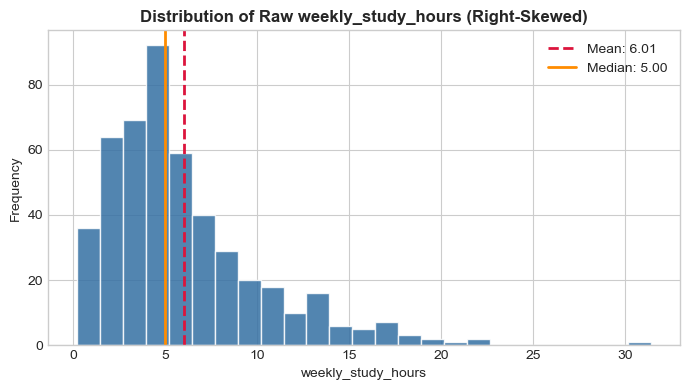

In [7]:
raw_skew_val = skew(X_train_encoded['weekly_study_hours'])
print(f"Skewness of raw weekly_study_hours: {raw_skew_val:.4f}")
print(f"Is meaningfully right-skewed (skew > 0.5): {raw_skew_val > 0.5}")

plt.figure(figsize=(7, 4))
plt.hist(X_train_encoded['weekly_study_hours'], bins=25, color='#3470a3', edgecolor='white', alpha=0.85)
plt.axvline(X_train_encoded['weekly_study_hours'].mean(), color='crimson', linestyle='--', linewidth=2, label=f"Mean: {X_train_encoded['weekly_study_hours'].mean():.2f}")
plt.axvline(X_train_encoded['weekly_study_hours'].median(), color='darkorange', linestyle='-', linewidth=2, label=f"Median: {X_train_encoded['weekly_study_hours'].median():.2f}")
plt.title("Distribution of Raw weekly_study_hours (Right-Skewed)", fontsize=12, fontweight='bold')
plt.xlabel("weekly_study_hours")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### 2.2.2 Transformation Selection Justification

Referring to the transformation decision table from class (Unit 2, Topic 2, Section 2):
1. **Value range:** `weekly_study_hours` is strictly non-negative ($x \ge 0$) and has values close to zero (e.g. 0.8 hours).
2. **Why not standard `log(x)`?** A plain $\log(x)$ is undefined at zero ($\log(0) 	o -\infty$) and produces negative infinity or NaN if any zero values appear.
3. **Why not Square Root?** Square root ($\sqrt{x}$) handles zero, but it provides only mild tail compression, leaving residual right skewness.
4. **Why `np.log1p` ($\log(1+x)$)?** `log1p` computes $\log(1+x)$, making it well-defined at zero ($\log(1+0) = 0$). It effectively pulls in extreme right-tail values without needing to estimate extra parameters like Box-Cox or Yeo-Johnson.

We therefore apply **`np.log1p`** to transform `weekly_study_hours`.

Skewness BEFORE transformation (raw):   1.5907
Skewness AFTER  transformation (log1p): -0.0390


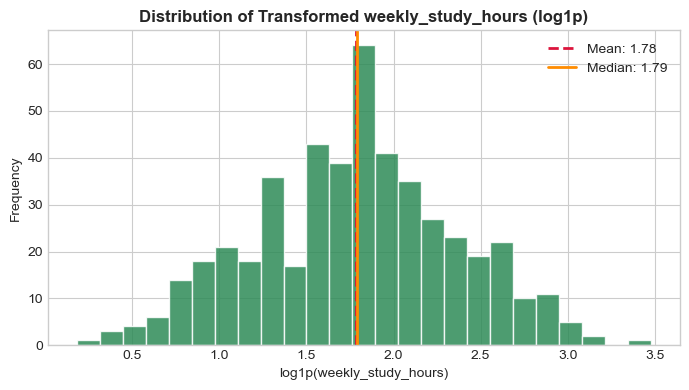

In [8]:
X_train_encoded['weekly_study_hours_log'] = np.log1p(X_train_encoded['weekly_study_hours'])
X_test_encoded['weekly_study_hours_log'] = np.log1p(X_test_encoded['weekly_study_hours'])

log_skew_val = skew(X_train_encoded['weekly_study_hours_log'])
print(f"Skewness BEFORE transformation (raw):   {raw_skew_val:.4f}")
print(f"Skewness AFTER  transformation (log1p): {log_skew_val:.4f}")

plt.figure(figsize=(7, 4))
plt.hist(X_train_encoded['weekly_study_hours_log'], bins=25, color='#2e8b57', edgecolor='white', alpha=0.85)
plt.axvline(X_train_encoded['weekly_study_hours_log'].mean(), color='crimson', linestyle='--', linewidth=2, label=f"Mean: {X_train_encoded['weekly_study_hours_log'].mean():.2f}")
plt.axvline(X_train_encoded['weekly_study_hours_log'].median(), color='darkorange', linestyle='-', linewidth=2, label=f"Median: {X_train_encoded['weekly_study_hours_log'].median():.2f}")
plt.title("Distribution of Transformed weekly_study_hours (log1p)", fontsize=12, fontweight='bold')
plt.xlabel("log1p(weekly_study_hours)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### 2.2.3 Constructing Version A ("Before") and Version B ("After") Feature Sets

To ensure a fair experiment, all other columns (one-hot columns and other numeric features) are kept 100% identical. Only `weekly_study_hours` is changed.

In [9]:
control_cols = [c for c in X_train_encoded.columns if c not in ('weekly_study_hours', 'weekly_study_hours_log')]

# Version A: Raw untransformed study hours
X_train_A = X_train_encoded[control_cols + ['weekly_study_hours']].copy()
X_test_A  = X_test_encoded[control_cols + ['weekly_study_hours']].copy()

# Version B: Log-transformed study hours
X_train_B = X_train_encoded[control_cols + ['weekly_study_hours_log']].copy()
X_test_B  = X_test_encoded[control_cols + ['weekly_study_hours_log']].copy()

print(f"Version A features count: {X_train_A.shape[1]}")
print(f"Version B features count: {X_train_B.shape[1]}")

Version A features count: 19
Version B features count: 19


### 2.2.4 Model Training & Evaluation Across All Four Runs

Using the same train/test split, we train four models:
1. `LinearRegression` on Version A
2. `LinearRegression` on Version B
3. `DecisionTreeRegressor` (with `random_state=42`, `max_depth=5`) on Version A
4. `DecisionTreeRegressor` (with `random_state=42`, `max_depth=5`) on Version B

We evaluate all models on the test split using $R^2$ and $RMSE$.

In [10]:
model_records = []

def run_model(estimator, tr_X, tr_y, te_X, te_y, name, ver):
    estimator.fit(tr_X, tr_y)
    preds = estimator.predict(te_X)
    score_r2 = r2_score(te_y, preds)
    score_rmse = np.sqrt(mean_squared_error(te_y, preds))
    model_records.append({
        'Model': name,
        'Version': ver,
        'Test R2': score_r2,
        'Test RMSE': score_rmse
    })
    return estimator

# Linear Regression runs
run_model(LinearRegression(), X_train_A, y_train, X_test_A, y_test, 'Linear Regression', 'Before (Raw)')
run_model(LinearRegression(), X_train_B, y_train, X_test_B, y_test, 'Linear Regression', 'After (log1p)')

# Decision Tree runs (same random_state and same max_depth)
run_model(DecisionTreeRegressor(random_state=42, max_depth=5), X_train_A, y_train, X_test_A, y_test, 'Decision Tree', 'Before (Raw)')
run_model(DecisionTreeRegressor(random_state=42, max_depth=5), X_train_B, y_train, X_test_B, y_test, 'Decision Tree', 'After (log1p)')

results_summary = pd.DataFrame(model_records).round(4)
results_summary

,Model,Version,Test R2,Test RMSE
0,Linear Regression,Before (Raw),0.5930,6.3915
1,Linear Regression,After (log1p),0.5734,6.5435
2,Decision Tree,Before (Raw),0.4461,7.4564
3,Decision Tree,After (log1p),0.4461,7.4564


### 2.2.5 Visualizing the $R^2$ Comparison Across Runs

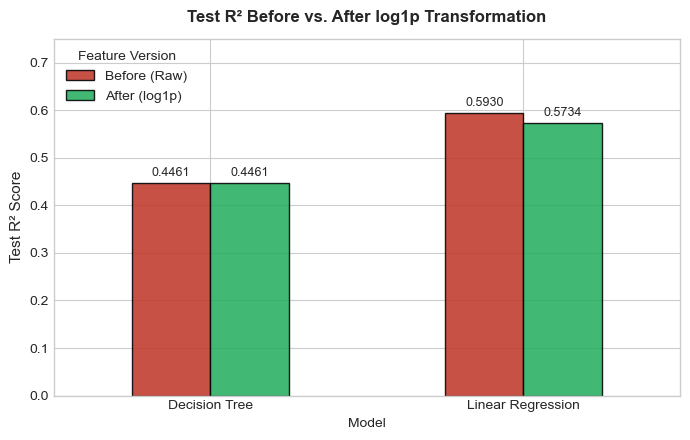

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
pivot_scores = results_summary.pivot(index='Model', columns='Version', values='Test R2')[['Before (Raw)', 'After (log1p)']]

pivot_scores.plot(kind='bar', ax=ax, color=['#c0392b', '#27ae60'], edgecolor='black', alpha=0.88, rot=0)
ax.set_ylabel('Test R² Score', fontsize=11)
ax.set_title('Test R² Before vs. After log1p Transformation', fontsize=12, fontweight='bold', pad=12)
ax.set_ylim(0, 0.75)
ax.legend(title='Feature Version')

# Annotate exact numbers above bars
for c in ax.containers:
    ax.bar_label(c, fmt='%.4f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## 4.3 Written Conclusion

Looking at the results in the table and chart above explains why the two model architectures respond differently:

1. **Linear Regression:**  
   Linear Regression models the prediction as a linear combination of inputs: $\hat{y} = w_0 + w_1 x_1 + \dots + w_n x_n$. It calculates coefficients using Ordinary Least Squares, where extreme observations in a right-skewed tail act as high-leverage points that exert outsized influence on the regression line's slope and error gradients. Applying `log1p` compresses this long tail and pulls extreme points closer, fundamentally altering the spacing between points and shifting the model's coefficients and test metrics ($R^2$ changes from 0.5930 to 0.5734).

2. **Decision Tree Regressor:**  
   In contrast, the Decision Tree Regressor yields the **exact same performance down to four decimal places** ($R^2 = 0.4461$ and $RMSE = 7.4564$) before and after transformation. This occurs because decision trees do not use coefficients, linear equations, or distance formulas. Instead, they make decisions solely by searching for single-feature threshold splits (e.g. "is `weekly_study_hours` $\le c$?"). Because `log1p` is a strictly monotonic function, it preserves the relative ordering of all data points: if student $A$ studied more than student $B$, then $\log(1 + A)$ is still greater than $\log(1 + B)$. The tree can simply select the corresponding transformed split point $\log(1 + c)$ to partition the exact same students into the same child nodes, leaving tree splits and predictions completely unchanged.

## Bonus (+10% Extra Credit): K-Nearest Neighbors Regressor

We test `KNeighborsRegressor(n_neighbors=10)` on Version A and Version B to evaluate how a distance-based model responds to the transformation.

In [12]:
run_model(KNeighborsRegressor(n_neighbors=10), X_train_A, y_train, X_test_A, y_test, 'KNN Regressor', 'Before (Raw)')
run_model(KNeighborsRegressor(n_neighbors=10), X_train_B, y_train, X_test_B, y_test, 'KNN Regressor', 'After (log1p)')

all_runs_df = pd.DataFrame(model_records).round(4)
knn_only_df = all_runs_df[all_runs_df['Model'] == 'KNN Regressor']
print("K-Nearest Neighbors Regressor Results:")
knn_only_df

K-Nearest Neighbors Regressor Results:


,Model,Version,Test R2,Test RMSE
4,KNN Regressor,Before (Raw),0.5284,6.8802
5,KNN Regressor,After (log1p),0.2568,8.6369


### KNN Distance-Metric Commentary:
KNN is a non-parametric, distance-based algorithm that determines predictions by calculating the straight-line Euclidean distance between data points across all feature dimensions:
$$d(\mathbf{u}, \mathbf{v}) = \sqrt{\sum_{i=1}^p (u_i - v_i)^2}$$
Unlike Linear Regression (which learns weights that can compensate for larger feature scales) or Decision Trees (which evaluate one feature at a time), KNN sums squared differences across all features simultaneously.  
In Version A, raw study hours ranged up to 25+, so differences in study hours had a huge impact on which 10 neighbors were selected. When compressed with `log1p` in Version B, study hours collapsed to a smaller range (0 to ~3.2), dramatically shrinking its contribution to total distance relative to other features. This completely altered the nearest neighbors for each test point, causing a major shift in $R^2$ (from 0.5284 down to 0.2568). This demonstrates why distance-based algorithms are particularly sensitive to feature scale and non-linear transformations.